In [1]:
%cd ..

f:\nn


# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import resample, shuffle

# Importing both DataFrames before and after augmentation

In [3]:
df_pre_aug = pd.read_csv('data/df_resized.csv')
display(df_pre_aug.head(10))
print("="*80)
df_augmented = pd.read_csv('data/df_augmented.csv')
display(df_augmented.head(10))

,path,class,resized_path
0,data\Bangunan Retak\Cracked\00001.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
1,data\Bangunan Retak\Cracked\00002.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
2,data\Bangunan Retak\Cracked\00003.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
3,data\Bangunan Retak\Cracked\00004.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
4,data\Bangunan Retak\Cracked\00005.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
5,data\Bangunan Retak\Cracked\00006.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
6,data\Bangunan Retak\Cracked\00007.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
7,data\Bangunan Retak\Cracked\00008.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
8,data\Bangunan Retak\Cracked\00009.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
9,data\Bangunan Retak\Cracked\00010.jpg,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...


,class,resized_path
0,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
1,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
2,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
3,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
4,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
5,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
6,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
7,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
8,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...
9,Cracked,data\cracked_vs_non_cracked_resized\Cracked\00...


# Visualizing Images imbalance

## Visualizing data before augmentation

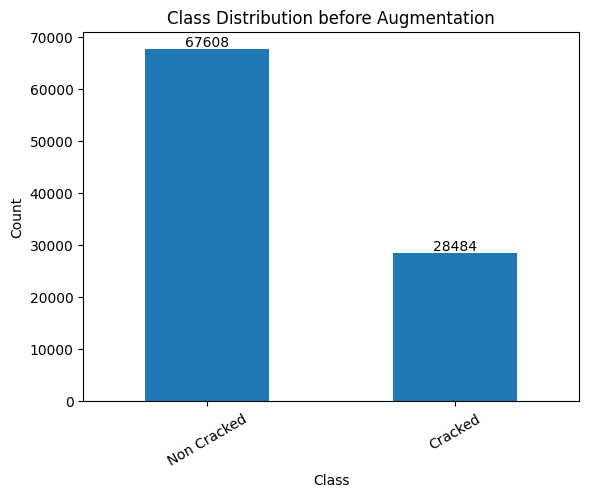

In [4]:
ax = df_pre_aug['class'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Class Distribution before Augmentation')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

## Visualizing data after augmentation

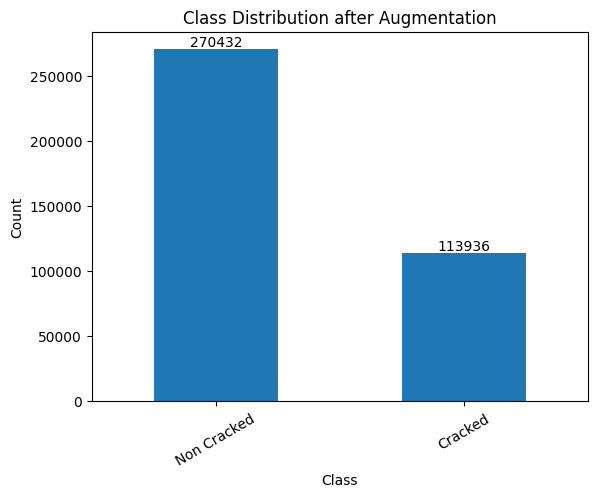

In [5]:
ax = df_augmented['class'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Class Distribution after Augmentation')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Balancing the distribution of the two classes

In [6]:
minority_class = df_augmented['class'].value_counts().idxmin()
majority_class = df_augmented['class'].value_counts().idxmax()

print(f"Minority class: {minority_class}")
print(f"Majority class: {majority_class}")

df_majorty_undersampled = resample(df_augmented[df_augmented['class'] == majority_class],
                                     replace=False,
                                     n_samples=len(df_augmented[df_augmented['class'] == minority_class]),
                                     random_state=42)

df = pd.concat([df_majorty_undersampled, df_augmented[df_augmented['class'] == minority_class]], ignore_index=True)

print("Undersampling done.")


Minority class: Cracked
Majority class: Non Cracked
Undersampling done.


## Visualizing the distribution of the data after balancing

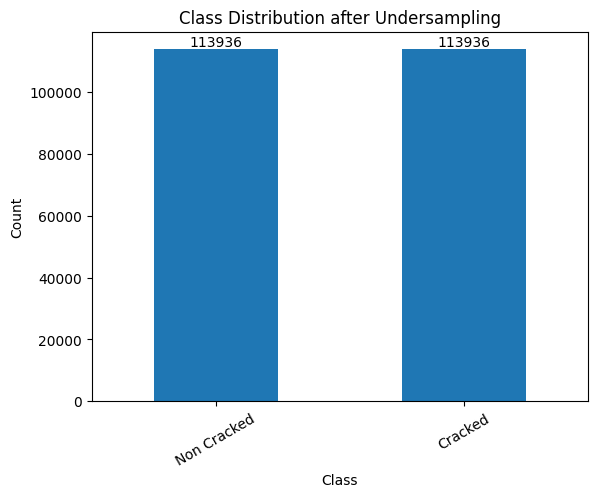

In [7]:
ax = df['class'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title('Class Distribution after Undersampling')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

In [8]:
print("Total number of samples after undersampling:", len(df))
print("="*80)
display(df.head(10))

Total number of samples after undersampling: 227872


,class,resized_path
0,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
1,Non Cracked,data\augmented_images\7050-6_resized_aug2.jpeg
2,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
3,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
4,Non Cracked,data\augmented_images\7119-100_resized_aug2.jpeg
5,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
6,Non Cracked,data\augmented_images\14397_resized_aug0.jpeg
7,Non Cracked,data\augmented_images\16418_resized_aug0.jpeg
8,Non Cracked,data\augmented_images\047-50_resized_aug1.jpeg
9,Non Cracked,data\augmented_images\7103-214_resized_aug1.jpeg


# Exporting our data to get

In [9]:
df.to_csv(r'data/trainable_df.csv', index=False)